In [1]:
#TMDB Extract

In [2]:
from src.etl.extract import Extract

extractor = Extract()
data = extractor.fetch_movies()

len(data)
data[0]

{'adult': False,
 'backdrop_path': '/iN41Ccw4DctL8npfmYg1j5Tr1eb.jpg',
 'genre_ids': [878, 12, 14],
 'id': 83533,
 'original_language': 'en',
 'original_title': 'Avatar: Fire and Ash',
 'overview': "In the wake of the devastating war against the RDA and the loss of their eldest son, Jake Sully and Neytiri face a new threat on Pandora: the Ash People, a violent and power-hungry Na'vi tribe led by the ruthless Varang. Jake's family must fight for their survival and the future of Pandora in a conflict that pushes them to their emotional and physical limits.",
 'popularity': 437.4182,
 'poster_path': '/bRBeSHfGHwkEpImlhxPmOcUsaeg.jpg',
 'release_date': '2025-12-17',
 'title': 'Avatar: Fire and Ash',
 'video': False,
 'vote_average': 7.373,
 'vote_count': 2421}

Basic Transform

In [3]:
from src.etl.transform import Transform

df = Transform.to_dataframe(data)

print(df.shape)
df.head()
df.describe()

Valid rows: 100
Invalid rows skipped: 0
(100, 6)


,movie_id,rating,popularity,release_year
count,1.000000e+02,100.000000,100.000000,100.000000
mean,4.754727e+05,7.250130,32.179571,2014.040000
std,5.250988e+05,1.063808,56.721089,13.042216
min,2.200000e+01,0.000000,10.805000,1939.000000
25%,2.012750e+03,6.930750,13.045775,2005.750000
50%,2.494040e+05,7.373500,18.373050,2016.500000
75%,9.832312e+05,7.897750,27.405175,2025.000000
max,1.575337e+06,8.534000,437.418200,2026.000000


In [4]:
df.isnull().sum()

movie_id        0
title           0
release_date    0
rating          0
popularity      0
release_year    0
dtype: int64

<Axes: title={'center': 'Movies per Year'}, xlabel='release_year'>

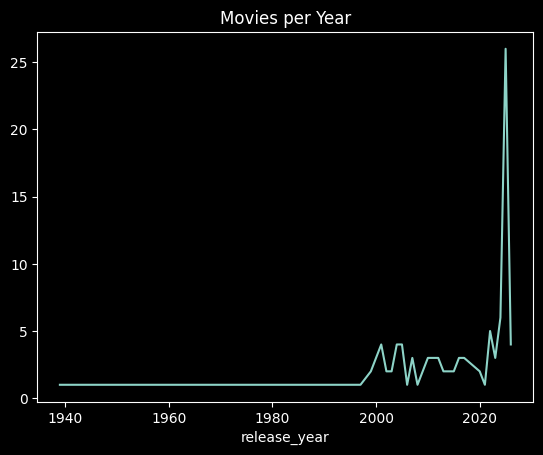

In [5]:
df.groupby("release_year").size().plot(title="Movies per Year")

In [6]:
df.sort_values(by="rating", ascending=False).head(10)[["title", "rating"]]

,title,rating
11,Spirited Away,8.534
23,The Green Mile,8.505
24,The Lord of the Rings: The Return of the King,8.500
79,The Legend of Hei 2,8.500
34,Cosmic Princess Kaguya!,8.438
18,The Lord of the Rings: The Fellowship of the Ring,8.430
45,The Lord of the Rings: The Two Towers,8.414
32,Howl's Moving Castle,8.387
13,Chainsaw Man - The Movie: Reze Arc,8.325
51,Princess Mononoke,8.324


In [7]:
import os
from dotenv import load_dotenv
import duckdb
from src.utils.paths import project_path

load_dotenv()

# Get DuckDB path from .env or fallback
DUCKDB_PATH_ENV = os.getenv("DUCKDB_PATH", "data/db/movies.duckdb")

# Resolve full absolute path relative to project root
DB_PATH = project_path(*DUCKDB_PATH_ENV.split("/"))  # works if env uses forward slashes
print("Resolved DuckDB path:", DB_PATH)

# Connect and query
con = duckdb.connect(DB_PATH)
df_db = con.execute("SELECT * FROM movies").fetchdf()
df_db.head()


Resolved DuckDB path: C:\Users\strom\code\Grupp7_Datavisualisering_DE_UX\data\db\movies.duckdb


,movie_id,title,release_date,rating,popularity,release_year
0,83533,Avatar: Fire and Ash,2025-12-17,7.373,485.097198,2025
1,1226863,The Super Mario Galaxy Movie,2026-04-01,6.953,317.093903,2026
2,502356,The Super Mario Bros. Movie,2023-04-05,7.587,225.702698,2023
3,1311031,Demon Slayer: Kimetsu no Yaiba Infinity Castle,2025-07-18,7.670,120.484398,2025
4,1159831,The Bride!,2026-03-04,6.300,91.137100,2026


In [8]:
con.close()

##Upcoming movies

In [9]:
from datetime import datetime

today = datetime.today().date()

unreleased = df[df["release_date"] > today]
unreleased.head()

,movie_id,title,release_date,rating,popularity,release_year
38,656908,Ramayana,2026-11-08,0.0,19.6315,2026
